Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import re
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, ReLU, Add, GlobalAveragePooling1D, Dense,
    LSTM, Bidirectional, AdditiveAttention, LayerNormalization, Dropout,
    SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report)

In [6]:
DATA_PATH = '../data/processed/signals/'

X_train_sig = np.load(os.path.join(DATA_PATH, 'X_train_sig.npy'))
y_train = np.load(os.path.join(DATA_PATH, 'y_train.npy'))
X_val_sig = np.load(os.path.join(DATA_PATH, 'X_val_sig.npy'))
y_val = np.load(os.path.join(DATA_PATH, 'y_val.npy'))
X_test_sig = np.load(os.path.join(DATA_PATH, 'X_test_sig.npy'))
y_test = np.load(os.path.join(DATA_PATH, 'y_test.npy'))

y_train_cat = to_categorical(y_train, num_classes=5)
y_val_cat = to_categorical(y_val, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

MODELS_PATH = '../models/'
os.makedirs(MODELS_PATH, exist_ok=True)

Ham sinyal segmentleri başarıyla yüklendi.
Eğitim seti sinyal boyutu: (136883, 250, 12)
Etiketler 'categorical' formata dönüştürüldü.
Modeller şu yola kaydedilecek: /content/drive/MyDrive/Colab_ECG_Data/models/


In [7]:
def build_lstm_with_attention(input_shape=(250, 12), num_classes=5):
    inputs = Input(shape=input_shape)

    x = SpatialDropout1D(0.1)(inputs)

    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = BatchNormalization()(x)

    attn_output = AdditiveAttention(name='attention_layer')([x, x])

    x = GlobalAveragePooling1D()(attn_output)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [8]:
def tcn_block(inputs, filters, kernel_size, dilation_rate):
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = SpatialDropout1D(0.1)(x)

    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = SpatialDropout1D(0.1)(x)

    if inputs.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding='same')(inputs)
    else:
        shortcut = inputs

    x = Add()([x, shortcut])
    x = ReLU()(x)
    return x

def build_tcn_with_attention(input_shape=(250, 12), num_classes=5):
    inputs = Input(shape=input_shape)

    x = tcn_block(inputs, 64, 3, dilation_rate=1)
    x = tcn_block(x, 64, 3, dilation_rate=2)
    x = tcn_block(x, 128, 3, dilation_rate=4)
    x = tcn_block(x, 128, 3, dilation_rate=8)

    attn_output = AdditiveAttention(name='attention_layer')([x, x])

    x = GlobalAveragePooling1D()(attn_output)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [9]:
def resnet_identity_block(inputs, filters, kernel_size):
    """Boyut değiştirmeyen ResNet bloğu"""
    shortcut = inputs

    x = Conv1D(filters, kernel_size, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv1D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)

    x = Add()([x, shortcut])
    x = ReLU()(x)
    return x

def resnet_conv_block(inputs, filters, kernel_size, strides):
    """Boyut değiştiren (azaltan) ResNet bloğu"""
    shortcut = inputs

    x = Conv1D(filters, kernel_size, strides=strides, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv1D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)

    # Shortcut'u da aynı boyuta getir
    shortcut = Conv1D(filters, 1, strides=strides, padding='same')(shortcut)
    shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = ReLU()(x)
    return x

def build_resnet34_with_attention(input_shape=(250, 12), num_classes=5):
    inputs = Input(shape=input_shape)

    # Giriş Katmanı
    x = Conv1D(64, 7, strides=2, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # ResNet-34 Blokları [3, 4, 6, 3]
    # Conv2_x (3 blok)
    x = resnet_identity_block(x, 64, 3)
    x = resnet_identity_block(x, 64, 3)
    x = resnet_identity_block(x, 64, 3)

    # Conv3_x (4 blok)
    x = resnet_conv_block(x, 128, 3, strides=2)
    x = resnet_identity_block(x, 128, 3)
    x = resnet_identity_block(x, 128, 3)
    x = resnet_identity_block(x, 128, 3)

    # Conv4_x (6 blok)
    x = resnet_conv_block(x, 256, 3, strides=2)
    x = resnet_identity_block(x, 256, 3)
    x = resnet_identity_block(x, 256, 3)
    x = resnet_identity_block(x, 256, 3)
    x = resnet_identity_block(x, 256, 3)
    x = resnet_identity_block(x, 256, 3)

    # Conv5_x (3 blok)
    x = resnet_conv_block(x, 512, 3, strides=2)
    x = resnet_identity_block(x, 512, 3)
    x = resnet_identity_block(x, 512, 3)

    # Attention Mekanizması
    # Modelin sonundaki diziyi (shape=(None, 32, 512)) alır
    attn_output = AdditiveAttention(name='attention_layer')([x, x])

    # Çıkış
    x = GlobalAveragePooling1D()(attn_output)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [10]:
models = {
    "LSTM_with_Attention": build_lstm_with_attention(),
    "TCN_with_Attention": build_tcn_with_attention(),
    "ResNet34_with_Attention": build_resnet34_with_attention()
}

results = {}

# MODELS_PATH = '/content/drive/MyDrive/Colab_ECG_Data/models/' # Google Drive yolu

for name, model in models.items():
    print(f"\n\n--- Model Eğitimi Başlıyor: {name} ---")

    current_batch_size = 32
    print(f"(Batch Size: {current_batch_size})")

    checkpoint_path_format = os.path.join(MODELS_PATH, f'checkpoint_{name.lower()}_epoch_{{epoch:02d}}.weights.h5')

    # ----- Kaldığı Yerden Devam Etme Mantığı -----
    initial_epoch_num = 0
    latest_checkpoint_file = None
    search_pattern = os.path.join(MODELS_PATH, f'checkpoint_{name.lower()}_epoch_*.weights.h5')
    checkpoint_files = glob.glob(search_pattern)
    if checkpoint_files:
        latest_epoch = -1
        for f in checkpoint_files:
            match = re.search(r'_epoch_(\d+)\.weights\.h5$', f)
            if match:
                epoch_num = int(match.group(1))
                if epoch_num > latest_epoch:
                    latest_epoch = epoch_num
                    latest_checkpoint_file = f
        if latest_checkpoint_file:
            try:
                # Modeli yeniden oluşturmak yerine mevcut 'model' nesnesine yükle
                model.load_weights(latest_checkpoint_file)
                initial_epoch_num = latest_epoch
                print(f"'{latest_checkpoint_file}' (Epoch {latest_epoch}) yüklendi. Eğitime Epoch {initial_epoch_num + 1}'den devam edilecek...")
            except Exception as e:
                print(f"Hata: Checkpoint dosyası '{latest_checkpoint_file}' yüklenemedi. Eğitime baştan başlanacak. (Hata: {e})")
                initial_epoch_num = 0
        else:
             print("Checkpoint dosyaları bulundu ancak epoch numarası okunamadı. Baştan başlanacak.")
    else:
        print("Daha önce kaydedilmiş checkpoint bulunamadı. Eğitime baştan başlanacak.")
    # ----- Kaldığı Yerden Devam Etme Mantığı Bitiş -----

    model_checkpoint_callback = ModelCheckpoint(
        filepath=checkpoint_path_format,
        save_weights_only=True,
        save_best_only=False,
        save_freq='epoch'
        )

    callbacks = [
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001),
        model_checkpoint_callback
    ]

    # Eğer initial_epoch_num 50'den büyük veya eşitse, eğitimi atla
    if initial_epoch_num < 50:
        history = model.fit(
            X_train_sig, y_train_cat,
            validation_data=(X_val_sig, y_val_cat),
            epochs=50,
            initial_epoch=initial_epoch_num, # Kaldığı yerden başla
            batch_size=current_batch_size,
            callbacks=callbacks,
            verbose=1
        )
    else:
        print(f"{name} için 50 epoch zaten tamamlanmış. Eğitim atlanıyor.")
        # Eğer eğitim atlandıysa, en son checkpoint'i yüklediğimizden emin olalım
        if latest_checkpoint_file:
             try:
                 model.load_weights(latest_checkpoint_file)
                 print(f"Eğitim atlandı, son checkpoint '{latest_checkpoint_file}' yüklendi.")
             except Exception as e:
                 print(f"Eğitim atlandı ancak son checkpoint yüklenemedi: {e}")


    print(f"\n--- {name} Model Değerlendirmesi (50. Epoch Sonu veya En Son Kayıt) (Test Seti) ---")

    # Metrik hesaplamaları
    preds_proba = model.predict(X_test_sig)
    preds = np.argmax(preds_proba, axis=1)
    y_true = y_test

    acc = accuracy_score(y_true, preds)
    bal_acc = balanced_accuracy_score(y_true, preds)
    prec_macro = precision_score(y_true, preds, average='macro', zero_division=0)
    rec_macro = recall_score(y_true, preds, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, preds, average='macro', zero_division=0)
    roc_auc_macro = roc_auc_score(y_test_cat, preds_proba, multi_class='ovr', average='macro')

    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test Balanced Accuracy: {bal_acc:.4f}")
    print(f"Test Precision (Macro): {prec_macro:.4f}")
    print(f"Test Recall (Macro): {rec_macro:.4f}")
    print(f"Test F1 Score (Macro): {f1_macro:.4f}")
    print(f"Test ROC AUC (Macro OVR): {roc_auc_macro:.4f}")

    report = classification_report(y_true, preds)
    print("\nSınıflandırma Raporu:")
    print(report)

    results[name] = {
        'accuracy': acc, 'balanced_accuracy': bal_acc, 'precision_macro': prec_macro,
        'recall_macro': rec_macro, 'f1_score_macro': f1_macro, 'roc_auc_ovr_macro': roc_auc_macro,
        'report': report
    }

    # Son modeli (50. epoch'taki haliyle) tam olarak kaydet
    model_path = os.path.join(MODELS_PATH, f'baseline_{name.lower()}_epoch50.h5')
    model.save(model_path)
    print(f"Baseline {name} modeli (50. epoch veya en son) '{model_path}' klasörüne kaydedildi.")

print("\n\n--- TÜM DERİN ÖĞRENME MODELLERİNİN EĞİTİMİ (50 EPOCH) TAMAMLANDI ---")

# Final özeti
print("\n--- Model Özet Sonuçları (50. Epoch Sonu) ---")
for name, metrics in results.items():
    print(f"\nModel: {name}")
    print(f"  Test Accuracy: {metrics['accuracy']:.4f}")
    print(f"  Test Balanced Accuracy: {metrics['balanced_accuracy']:.4f}")
    print(f"  Test F1 Score (Macro): {metrics['f1_score_macro']:.4f}")



--- Model Eğitimi Başlıyor: LSTM_with_Attention ---
(Batch Size: 32)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 28 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


'/content/drive/MyDrive/Colab_ECG_Data/models/checkpoint_lstm_with_attention_epoch_50.weights.h5' (Epoch 50) yüklendi. Eğitime Epoch 51'den devam edilecek...
LSTM_with_Attention için 50 epoch zaten tamamlanmış. Eğitim atlanıyor.
Eğitim atlandı, son checkpoint '/content/drive/MyDrive/Colab_ECG_Data/models/checkpoint_lstm_with_attention_epoch_50.weights.h5' yüklendi.

--- LSTM_with_Attention Model Değerlendirmesi (50. Epoch Sonu veya En Son Kayıt) (Test Seti) ---
535/535 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step


Test Accuracy: 0.9509
Test Balanced Accuracy: 0.9284
Test Precision (Macro): 0.9405
Test Recall (Macro): 0.9284
Test F1 Score (Macro): 0.9321
Test ROC AUC (Macro OVR): 0.9970

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      2152
           1       0.98      0.82      0.89      1053
           2       0.97      0.95      0.96      4375
           3       0.97      0.97      0.97      7611
           4       0.82      0.96      0.88      1920

    accuracy                           0.95     17111
   macro avg       0.94      0.93      0.93     17111
weighted avg       0.95      0.95      0.95     17111

Baseline LSTM_with_Attention modeli (50. epoch veya en son) '/content/drive/MyDrive/Colab_ECG_Data/models/baseline_lstm_with_attention_epoch50.h5' klasörüne kaydedildi.


--- Model Eğitimi Başlıyor: TCN_with_Attention ---
(Batch Size: 32)
Daha önce kaydedilmiş checkpoint bulunamadı. Eğitime baştan başlanacak.
Ep

Test Accuracy: 0.9284
Test Balanced Accuracy: 0.8642
Test Precision (Macro): 0.9408
Test Recall (Macro): 0.8642
Test F1 Score (Macro): 0.8953
Test ROC AUC (Macro OVR): 0.9954

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.98      0.86      0.92      2152
           1       0.98      0.68      0.80      1053
           2       0.91      0.97      0.94      4375
           3       0.93      0.98      0.96      7611
           4       0.90      0.83      0.86      1920

    accuracy                           0.93     17111
   macro avg       0.94      0.86      0.90     17111
weighted avg       0.93      0.93      0.93     17111

Baseline TCN_with_Attention modeli (50. epoch veya en son) '/content/drive/MyDrive/Colab_ECG_Data/models/baseline_tcn_with_attention_epoch50.h5' klasörüne kaydedildi.


--- Model Eğitimi Başlıyor: ResNet34_with_Attention ---
(Batch Size: 32)
Daha önce kaydedilmiş checkpoint bulunamadı. Eğitime baştan başlanacak.

Test Accuracy: 0.9745
Test Balanced Accuracy: 0.9667
Test Precision (Macro): 0.9721
Test Recall (Macro): 0.9667
Test F1 Score (Macro): 0.9694
Test ROC AUC (Macro OVR): 0.9986

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      2152
           1       0.97      0.95      0.96      1053
           2       0.97      0.98      0.98      4375
           3       0.98      0.98      0.98      7611
           4       0.95      0.96      0.95      1920

    accuracy                           0.97     17111
   macro avg       0.97      0.97      0.97     17111
weighted avg       0.97      0.97      0.97     17111

Baseline ResNet34_with_Attention modeli (50. epoch veya en son) '/content/drive/MyDrive/Colab_ECG_Data/models/baseline_resnet34_with_attention_epoch50.h5' klasörüne kaydedildi.


--- TÜM DERİN ÖĞRENME MODELLERİNİN EĞİTİMİ (50 EPOCH) TAMAMLANDI ---

--- Model Özet Sonuçları (50. Epoch Sonu) ---

Model: LSTM_with_


--- DERİN ÖĞRENME MODELLERİ KARŞILAŞTIRMALI SONUÇ TABLOSU (TEST SETİ) ---
                         accuracy  balanced_accuracy  precision_macro  \
LSTM_with_Attention        0.9509             0.9284           0.9405   
TCN_with_Attention         0.9284             0.8642           0.9408   
ResNet34_with_Attention    0.9745             0.9667           0.9721   

                         recall_macro  f1_score_macro  roc_auc_ovr_macro  
LSTM_with_Attention            0.9284          0.9321             0.9970  
TCN_with_Attention             0.8642          0.8953             0.9954  
ResNet34_with_Attention        0.9667          0.9694             0.9986  


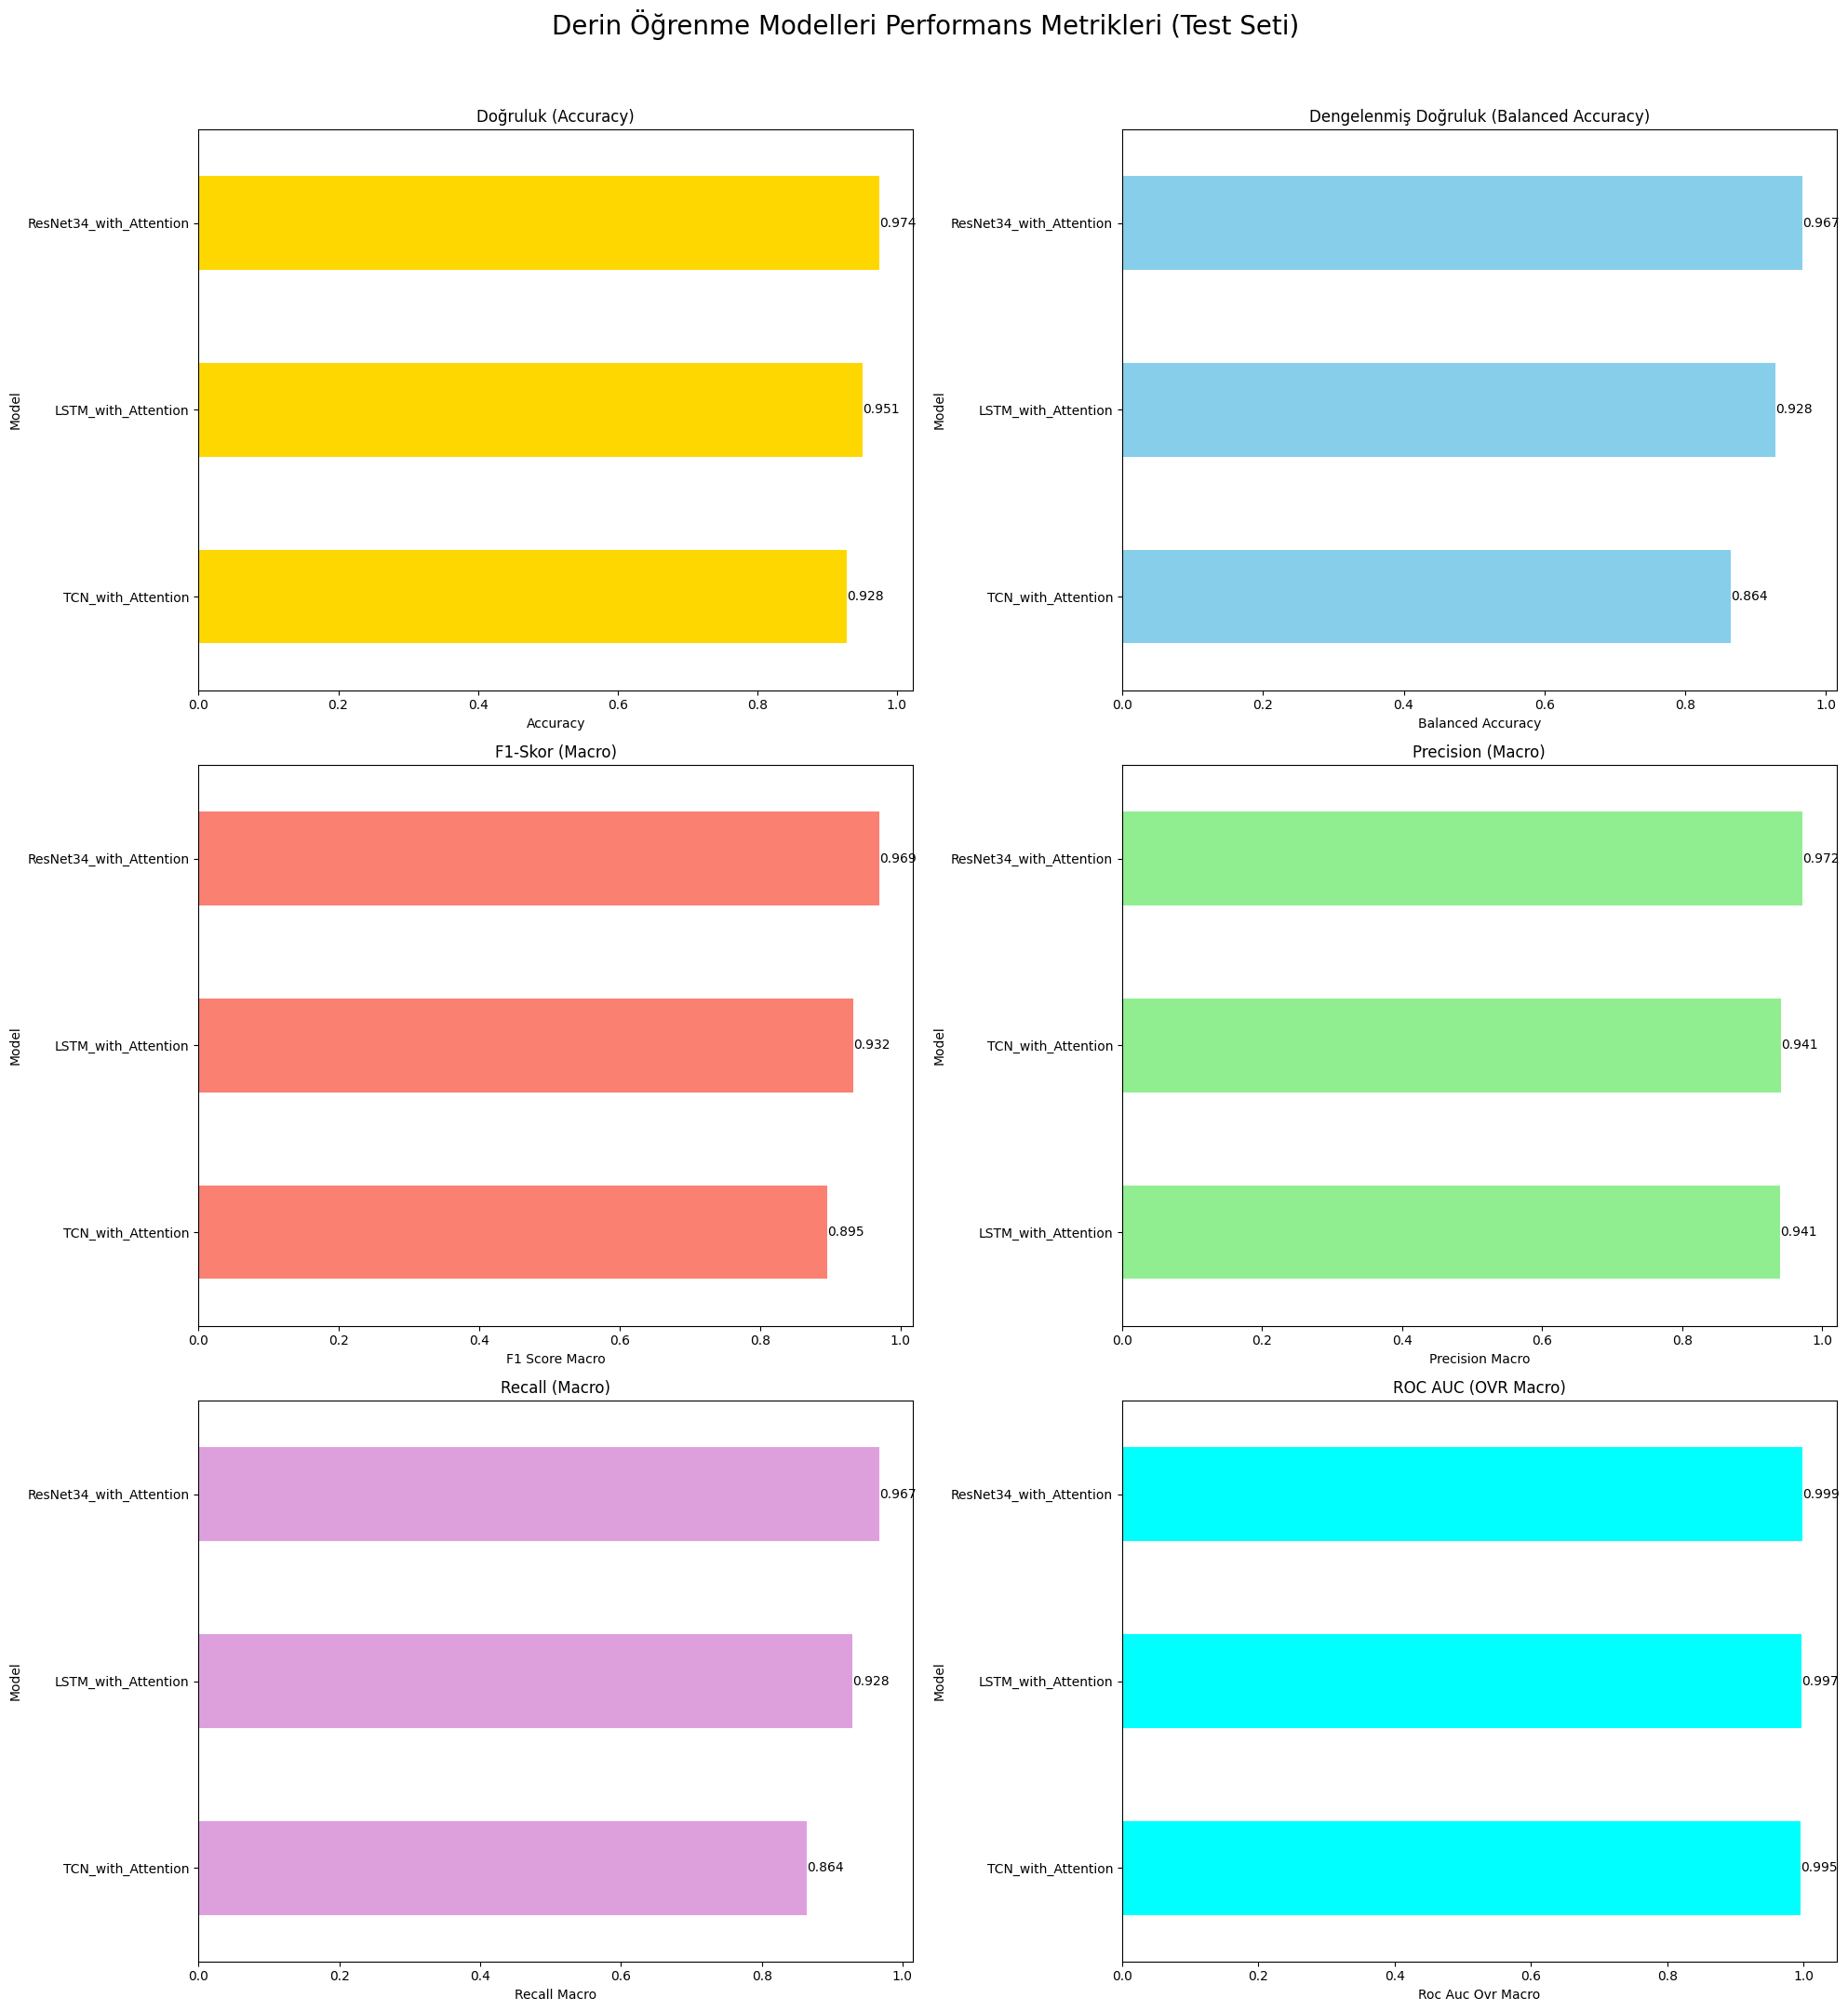

In [12]:
# --- HÜCRE 8: DERİN ÖĞRENME MODELLERİ SONUÇ GÖRSELLEŞTİRME ---
 # Daha hoş grafikler için

# Hücre 5'te doldurulan 'results' sözlüğünün var olduğunu varsayıyoruz.
if 'results' in locals() and results: # 'results' tanımlı ve boş değilse
    results_for_df = {}
    for model_name, metrics_dict in results.items():
        for metric_name, value in metrics_dict.items():
            if metric_name != 'report': # classification_report'u atla
                if metric_name not in results_for_df:
                    results_for_df[metric_name] = {}
                results_for_df[metric_name][model_name] = value

    results_df_dl = pd.DataFrame(results_for_df)

    print("\n--- DERİN ÖĞRENME MODELLERİ KARŞILAŞTIRMALI SONUÇ TABLOSU (TEST SETİ) ---")
    print(results_df_dl.round(4))

    # Görselleştirme
    fig, axes = plt.subplots(3, 2, figsize=(20, 22))
    fig.suptitle('Derin Öğrenme Modelleri Performans Metrikleri (Test Seti)', fontsize=20)
    axes = axes.flatten() # 3x2 grid'i tek diziye çevir

    metrics_to_plot = {
        'accuracy': 'Doğruluk (Accuracy)',
        'balanced_accuracy': 'Dengelenmiş Doğruluk (Balanced Accuracy)',
        'f1_score_macro': 'F1-Skor (Macro)',
        'precision_macro': 'Precision (Macro)',
        'recall_macro': 'Recall (Macro)',
        'roc_auc_ovr_macro': 'ROC AUC (OVR Macro)'
    }
    # Klasik ML grafikleriyle aynı renkleri kullanabiliriz
    colors = ['gold', 'skyblue', 'salmon', 'lightgreen', 'plum', 'cyan']

    plot_counter = 0 # Eksenleri doğru kullanmak için sayaç
    for i, (metric, title) in enumerate(metrics_to_plot.items()):
        if metric in results_df_dl.columns: # Eğer metrik hesaplanmışsa
            ax = axes[plot_counter]
            results_df_dl[metric].sort_values().plot(
                kind='barh', ax=ax, color=colors[i], title=title
            )
            ax.set_xlabel(metric.replace('_', ' ').title())
            ax.set_ylabel("Model") # Y ekseni etiketini ekleyelim
            # Barların üzerine değerleri yazdır
            for container in ax.containers:
                ax.bar_label(container, fmt='%.3f')
            plot_counter += 1 # Bir sonraki eksene geç

    # Kullanılmayan subplot'ları gizle
    if plot_counter < len(axes):
        for i in range(plot_counter, len(axes)):
            axes[i].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ana başlığın üzerine binmesini engelle
    plt.show()

else:
    print("\n'results' sözlüğü bulunamadı veya boş. Lütfen önce Hücre 5'i çalıştırıp modelleri eğitin.")

In [18]:
# --- HÜCRE 6: Belirli Epoch'ların Test Sonuçlarını Hesaplama ---
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, classification_report)
import pandas as pd
import glob
import re
import os
import numpy as np
from tensorflow.keras.utils import to_categorical
import tensorflow as tf # model.evaluate ve build fonksiyonları için gerekli

print("--- Belirli Epoch'ların Test Seti Üzerinde Değerlendirilmesi ---")

# Değerlendirilecek modellerin build fonksiyonları
model_builders = {
    "LSTM_with_Attention": build_lstm_with_attention,
    "TCN_with_Attention": build_tcn_with_attention,
    "ResNet34_with_Attention": build_resnet34_with_attention
}

# İlgilendiğimiz epoch'lar
target_epochs = [10, 20, 30, 40, 50]

results_specific_epochs = [] # Tüm sonuçları burada toplayacağız

# MODELS_PATH = '/content/drive/MyDrive/Colab_ECG_Data/models/' # Google Drive yolu

# Gerekli Test verisini yükle - Bellekte yoksa
try:
    if 'X_test_sig' not in locals() or 'y_test' not in locals() or 'y_test_cat' not in locals():
        print("Test verisi yükleniyor...")
        # DRIVE_DATA_PATH tanımlı olmalı (Hücre 2'den)
        if 'DRIVE_DATA_PATH' not in locals():
             DRIVE_DATA_PATH = '/content/drive/MyDrive/Colab_ECG_Data/' # Varsayılan yol

        X_test_sig = np.load(os.path.join(DRIVE_DATA_PATH, 'X_test_sig.npy'))
        y_test = np.load(os.path.join(DRIVE_DATA_PATH, 'y_test.npy'))
        y_test_cat = to_categorical(y_test, num_classes=5)
    print("Değerlendirme için Test verisi hazır.")
except NameError as e:
    print(f"Hata: Gerekli değişkenler (örn: DRIVE_DATA_PATH) tanımlı değil. Önceki hücreleri çalıştırın. {e}")
    raise SystemExit("Devam edilemiyor.")
except Exception as e:
    print(f"Hata: Test verisi yüklenemedi. {e}")
    raise SystemExit("Devam edilemiyor.")


for name, model_build_function in model_builders.items():
    print(f"\n--- Model: {name} ---")

    # Modeli oluştur ve compile et (her model için bir kez yeterli)
    try:
        model = model_build_function()
        model.compile(optimizer='adamw', loss='categorical_crossentropy', metrics=['accuracy'])
        print(f"  {name} modeli oluşturuldu.")
    except Exception as e:
        print(f"  Hata: {name} modeli oluşturulamadı. Bu model atlanıyor. Hata: {e}")
        continue

    # Belirlenen epoch'lar için ağırlıkları yükle ve değerlendir
    for epoch_num in target_epochs:
        print(f"  Epoch {epoch_num} değerlendiriliyor...")
        checkpoint_path = os.path.join(MODELS_PATH, f'checkpoint_{name.lower()}_epoch_{epoch_num:02d}.weights.h5')

        if not os.path.exists(checkpoint_path):
            print(f"    Uyarı: Epoch {epoch_num} checkpoint dosyası bulunamadı ({checkpoint_path}). Atlanıyor.")
            continue

        try:
            model.load_weights(checkpoint_path) # Ağırlıkları yükle

            # Test seti üzerinde tahmin yap
            preds_proba = model.predict(X_test_sig, verbose=0) # verbose=0 sessiz çalışır
            preds = np.argmax(preds_proba, axis=1)
            y_true = y_test

            # Metrikleri hesapla
            acc = accuracy_score(y_true, preds)
            bal_acc = balanced_accuracy_score(y_true, preds)
            prec_macro = precision_score(y_true, preds, average='macro', zero_division=0)
            rec_macro = recall_score(y_true, preds, average='macro', zero_division=0)
            f1_macro = f1_score(y_true, preds, average='macro', zero_division=0)
            roc_auc_macro = roc_auc_score(y_test_cat, preds_proba, multi_class='ovr', average='macro')

            # Sonuçları listeye ekle
            results_specific_epochs.append({
                'model': name,
                'epoch': epoch_num,
                'accuracy': acc,
                'balanced_accuracy': bal_acc,
                'precision_macro': prec_macro,
                'recall_macro': rec_macro,
                'f1_score_macro': f1_macro,
                'roc_auc_ovr_macro': roc_auc_macro
            })
            print(f"    Epoch {epoch_num}: Balanced Accuracy = {bal_acc:.4f}")

        except Exception as e:
            print(f"    Hata: Epoch {epoch_num} yüklenemedi veya değerlendirilemedi. Detay: {e}")

print("\n\n--- BELİRLİ EPOCH'LAR İÇİN DEĞERLENDİRME TAMAMLANDI ---")

# --- Sonuçları DataFrame'e Çevirme ve Gösterme ---
if results_specific_epochs:
    results_df_specific = pd.DataFrame(results_specific_epochs)
    # Daha okunaklı olması için Modeli ve Epoch'u index yapalım
    results_df_specific.set_index(['model', 'epoch'], inplace=True)
    print("\n--- Model ve Epoch Bazında Test Seti Sonuçları ---")
    print(results_df_specific.round(4))
else:
    print("\nHiçbir epoch başarıyla değerlendirilemedi.")
    results_df_specific = pd.DataFrame() # Boş DataFrame oluştur

--- Belirli Epoch'ların Test Seti Üzerinde Değerlendirilmesi ---
Değerlendirme için Test verisi hazır.

--- Model: LSTM_with_Attention ---
  LSTM_with_Attention modeli oluşturuldu.
  Epoch 10 değerlendiriliyor...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 28 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


    Epoch 10: Balanced Accuracy = 0.7447
  Epoch 20 değerlendiriliyor...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 28 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


    Epoch 20: Balanced Accuracy = 0.8407
  Epoch 30 değerlendiriliyor...


...

    Epoch 30: Balanced Accuracy = 0.9043
  Epoch 40 değerlendiriliyor...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 296 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


    Epoch 40: Balanced Accuracy = 0.9646
  Epoch 50 değerlendiriliyor...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 296 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


    Epoch 50: Balanced Accuracy = 0.9667


--- BELİRLİ EPOCH'LAR İÇİN DEĞERLENDİRME TAMAMLANDI ---

--- Model ve Epoch Bazında Test Seti Sonuçları ---
                               accuracy  balanced_accuracy  precision_macro  \
model                   epoch                                                 
LSTM_with_Attention     10       0.8329             0.7447           0.8204   
                        20       0.8943             0.8407           0.8883   
                        30       0.9231             0.8872           0.9152   
                        40       0.9414             0.9240           0.9259   
                        50       0.9509             0.9284           0.9405   
TCN_with_Attention      10       0.8399             0.7671           0.8151   
                        20       0.8868             0.8512           0.8558   
                        30       0.9066             0.8466           0.9088   
                        40       0.9206             0.8665 